In [3]:
!pip install pandasql -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pandasql import sqldf

In [4]:
df = pd.read_csv('/kaggle/input/datasets/dubradave/hospital-readmissions/hospital_readmissions.csv')


print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nReadmitted values:", df['readmitted'].value_counts())
print("\nMissing values:\n", df.isnull().sum())

Shape: (25000, 17)

Columns: ['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted']

Readmitted values: readmitted
no     13246
yes    11754
Name: count, dtype: int64

Missing values:
 age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64


In [5]:
df = df.dropna(subset=['age', 'readmitted', 'diag_1'])


df['readmitted_30day'] = df['readmitted'].apply(lambda x: 1 if x == 'yes' else 0)


age_map = {
    '[0-10)':5,'[10-20)':15,'[20-30)':25,'[30-40)':35,
    '[40-50)':45,'[50-60)':55,'[60-70)':65,
    '[70-80)':75,'[80-90)':85,'[90-100)':95
}
df['age_numeric'] = df['age'].map(age_map)

print("Clean dataset shape:", df.shape)
print("Overall readmission rate:", round(df['readmitted_30day'].mean() * 100, 2), "%")

Clean dataset shape: (25000, 19)
Overall readmission rate: 47.02 %


In [6]:
pysql = lambda q: sqldf(q, globals())

q1 = pysql("""
    SELECT
        COUNT(*) AS total_patients,
        SUM(readmitted_30day) AS readmitted_count,
        ROUND(SUM(readmitted_30day) * 100.0 / COUNT(*), 2) AS readmission_rate_pct
    FROM df
""")
print("Q1 — Overall readmission rate:")
print(q1.to_string(index=False))

Q1 — Overall readmission rate:
 total_patients  readmitted_count  readmission_rate_pct
          25000             11754                 47.02


In [7]:
q2 = pysql("""
    SELECT
        age,
        COUNT(*) AS total_patients,
        SUM(readmitted_30day) AS readmissions,
        ROUND(SUM(readmitted_30day) * 100.0 / COUNT(*), 2) AS rate_pct
    FROM df
    GROUP BY age
    ORDER BY rate_pct DESC
""")
print("Q2 — Readmission rate by age group:")
print(q2.to_string(index=False))

Q2 — Readmission rate by age group:
     age  total_patients  readmissions  rate_pct
 [80-90)            4516          2239     49.58
 [70-80)            6837          3336     48.79
 [60-70)            5913          2770     46.85
 [40-50)            2532          1127     44.51
 [50-60)            4452          1966     44.16
[90-100)             750           316     42.13


In [8]:
q3 = pysql("""
    SELECT
        diag_1,
        COUNT(*) AS total_cases,
        SUM(readmitted_30day) AS readmissions,
        ROUND(SUM(readmitted_30day) * 100.0 / COUNT(*), 2) AS rate_pct
    FROM df
    GROUP BY diag_1
    ORDER BY readmissions DESC
    LIMIT 10
""")
print("Q3 — Top 10 diagnoses by readmission count:")
print(q3.to_string(index=False))

Q3 — Top 10 diagnoses by readmission count:
         diag_1  total_cases  readmissions  rate_pct
    Circulatory         7824          3750     47.93
          Other         6498          2932     45.12
    Respiratory         3680          1806     49.08
      Digestive         2329          1105     47.45
       Diabetes         1747           937     53.63
         Injury         1666           727     43.64
Musculoskeletal         1252           495     39.54
        Missing            4             2     50.00


In [9]:
q4 = pysql("""
    SELECT
        n_medications,
        COUNT(*) AS patients,
        ROUND(AVG(readmitted_30day) * 100, 2) AS readmission_rate_pct
    FROM df
    GROUP BY n_medications
    ORDER BY n_medications
""")
print("Q4 — Number of medications vs readmission rate:")
print(q4.to_string(index=False))

Q4 — Number of medications vs readmission rate:
 n_medications  patients  readmission_rate_pct
             1        66                 39.39
             2        83                 28.92
             3       198                 36.87
             4       275                 36.00
             5       419                 37.95
             6       631                 35.50
             7       828                 38.04
             8      1052                 44.01
             9      1157                 42.09
            10      1268                 43.22
            11      1396                 47.56
            12      1509                 45.66
            13      1459                 47.84
            14      1396                 48.21
            15      1469                 49.42
            16      1379                 48.80
            17      1271                 49.49
            18      1140                 51.58
            19      1021                 49.76
            

In [10]:
q5 = pysql("""
    SELECT
        age,
        n_medications,
        COUNT(*) AS patients,
        ROUND(AVG(readmitted_30day) * 100, 2) AS readmission_rate_pct
    FROM df
    WHERE age_numeric >= 60
    GROUP BY age, n_medications
    HAVING COUNT(*) > 50
    ORDER BY readmission_rate_pct DESC
    LIMIT 10
""")
print("Q5 — High-risk segments (age 60+, high medication count):")
print(q5.to_string(index=False))

Q5 — High-risk segments (age 60+, high medication count):
    age  n_medications  patients  readmission_rate_pct
[70-80)             23       180                 59.44
[80-90)             25        69                 59.42
[60-70)             25       156                 58.97
[80-90)             21       136                 58.09
[70-80)             24       125                 56.80
[80-90)             15       283                 55.48
[70-80)             17       346                 55.20
[70-80)             22       205                 55.12
[80-90)             23       118                 55.08
[70-80)             20       253                 54.94


In [11]:
print("=" * 50)
print("Q1 — OVERALL READMISSION RATE")
print("=" * 50)
print(q1.to_string(index=False))

print("\n" + "=" * 50)
print("Q2 — READMISSION RATE BY AGE GROUP")
print("=" * 50)
print(q2.to_string(index=False))

print("\n" + "=" * 50)
print("Q3 — TOP 10 DIAGNOSES BY READMISSION COUNT")
print("=" * 50)
print(q3.to_string(index=False))

print("\n" + "=" * 50)
print("Q4 — MEDICATIONS VS READMISSION RATE")
print("=" * 50)
print(q4.to_string(index=False))

print("\n" + "=" * 50)
print("Q5 — HIGH RISK SEGMENTS (AGE 60+)")
print("=" * 50)
print(q5.to_string(index=False))

Q1 — OVERALL READMISSION RATE
 total_patients  readmitted_count  readmission_rate_pct
          25000             11754                 47.02

Q2 — READMISSION RATE BY AGE GROUP
     age  total_patients  readmissions  rate_pct
 [80-90)            4516          2239     49.58
 [70-80)            6837          3336     48.79
 [60-70)            5913          2770     46.85
 [40-50)            2532          1127     44.51
 [50-60)            4452          1966     44.16
[90-100)             750           316     42.13

Q3 — TOP 10 DIAGNOSES BY READMISSION COUNT
         diag_1  total_cases  readmissions  rate_pct
    Circulatory         7824          3750     47.93
          Other         6498          2932     45.12
    Respiratory         3680          1806     49.08
      Digestive         2329          1105     47.45
       Diabetes         1747           937     53.63
         Injury         1666           727     43.64
Musculoskeletal         1252           495     39.54
        Mis

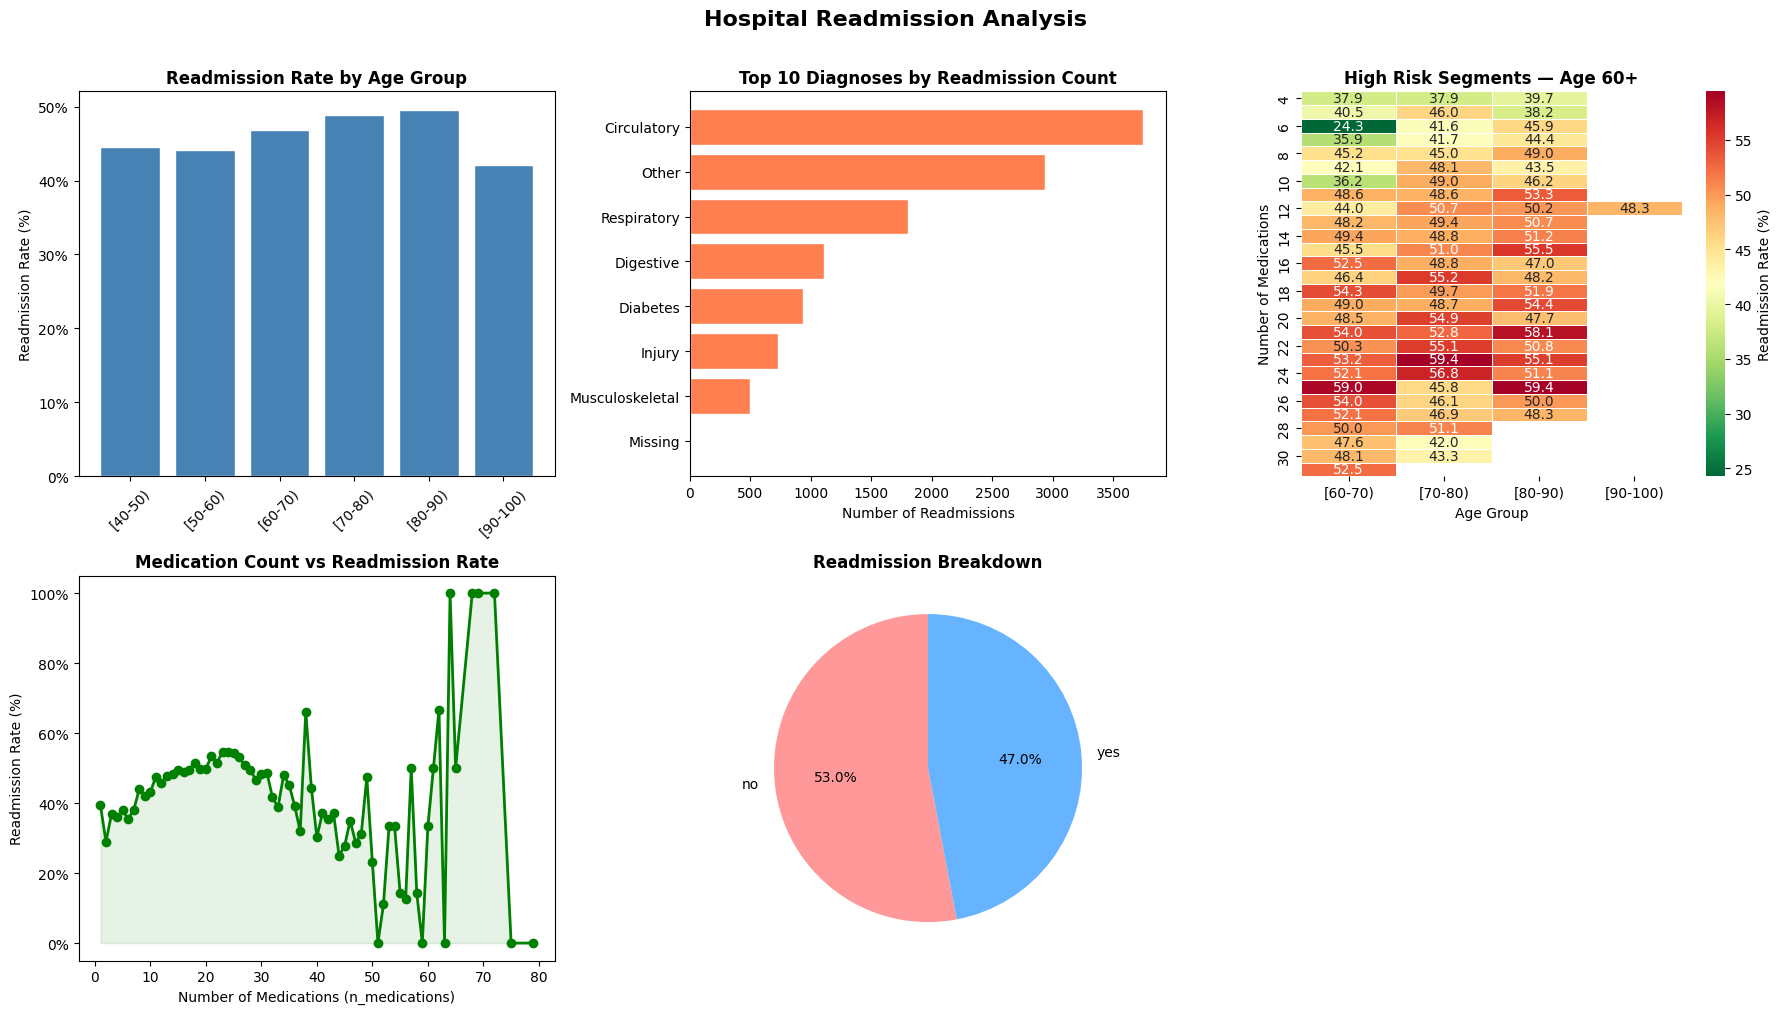

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Hospital Readmission Analysis', fontsize=16, fontweight='bold', y=1.01)

# Chart 1: Readmission rate by age
age_order = ['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)',
             '[50-60)','[60-70)','[70-80)','[80-90)','[90-100)']
age_data = df.groupby('age')['readmitted_30day'].mean() * 100
age_data = age_data.reindex([a for a in age_order if a in age_data.index])
axes[0,0].bar(age_data.index, age_data.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Readmission Rate by Age Group', fontweight='bold')
axes[0,0].set_ylabel('Readmission Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Chart 2: Top 10 diagnoses
top_diag = df.groupby('diag_1')['readmitted_30day'].sum().sort_values(ascending=False).head(10)
axes[0,1].barh(top_diag.index, top_diag.values, color='coral', edgecolor='white')
axes[0,1].set_title('Top 10 Diagnoses by Readmission Count', fontweight='bold')
axes[0,1].set_xlabel('Number of Readmissions')
axes[0,1].invert_yaxis()

# Chart 3: n_medications vs readmission rate
med_data = df.groupby('n_medications')['readmitted_30day'].mean() * 100
axes[1,0].plot(med_data.index, med_data.values, marker='o', color='green', linewidth=2)
axes[1,0].fill_between(med_data.index, med_data.values, alpha=0.1, color='green')
axes[1,0].set_title('Medication Count vs Readmission Rate', fontweight='bold')
axes[1,0].set_xlabel('Number of Medications (n_medications)')
axes[1,0].set_ylabel('Readmission Rate (%)')
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Chart 4: Readmission breakdown
breakdown = df['readmitted'].value_counts()
axes[1,1].pie(breakdown.values, labels=breakdown.index, autopct='%1.1f%%',
              colors=['#ff9999','#66b3ff'], startangle=90)
axes[1,1].set_title('Readmission Breakdown', fontweight='bold')

# Chart 5: Heatmap — High risk segments (Q5)
pivot = df[df['age_numeric'] >= 60].groupby(
    ['age', 'n_medications'])['readmitted_30day'].agg(
    ['mean', 'count']).reset_index()
pivot = pivot[pivot['count'] > 50]
pivot['readmission_rate'] = pivot['mean'] * 100
heatmap_data = pivot.pivot(
    index='n_medications',
    columns='age',
    values='readmission_rate'
)
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': 'Readmission Rate (%)'},
    ax=axes[0,2]
)
axes[0,2].set_title('High Risk Segments — Age 60+', fontweight='bold')
axes[0,2].set_xlabel('Age Group')
axes[0,2].set_ylabel('Number of Medications')

# Hide the 6th empty subplot
axes[1,2].set_visible(False)

plt.tight_layout()
plt.savefig('readmission_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()